<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/18_classification/18_6_Ensemble/18_6_4_Model_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Comparison: All Ensemble Methods Head-to-Head

**Author:** Brad Sheese

---

## Introduction

Over the past three notebooks, we've explored five methods for tree-based classification:

1. **Single Decision Tree** — interpretable but unstable
2. **Bagging** — reduces variance through bootstrap averaging
3. **Random Forest** — adds feature randomness to decorrelate trees
4. **Gradient Boosting** — reduces bias through sequential error correction
5. **BART** — Bayesian approach with uncertainty quantification

In this final notebook, we'll compare them all using **nested cross-validation** for unbiased performance estimates — the same technique we used in 17_2_1_4 and 17_2_1_5 for regression.

### Learning Objectives
1. Apply nested cross-validation to compare multiple classification models.
2. Interpret the bias-variance tradeoff across all five methods.
3. Choose the right ensemble method for a given problem context.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    BaggingClassifier, AdaBoostClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_context("talk")
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Flip target: 1=malignant, 0=benign (matching original UCI encoding)
y = 1 - y

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class distribution: {y.value_counts(normalize=True).to_dict()}")

Dataset: 569 samples, 30 features
Class distribution: {0: 0.6274165202108963, 1: 0.37258347978910367}


---
## Nested Cross-Validation for Unbiased Comparison

Recall from 17_2_1_5: nested CV uses an inner loop to tune hyperparameters and an outer loop to evaluate. This gives us an unbiased estimate of each model's performance, accounting for the fact that hyperparameter selection itself introduces optimistic bias.

### How It Works Here:
- **Outer loop**: 5-fold CV for evaluation
- **Inner loop**: 3-fold CV for hyperparameter tuning within each outer fold

For each model, we define a small hyperparameter grid. The inner loop finds the best params for each outer training fold, and the outer loop evaluates on the held-out fold.

**Runtime note:** This cell runs GridSearchCV inside cross-validation for 4 models. The total number of model fits is:
- Decision Tree: 5 outer × 3 inner × 4 depth values = **60 fits**
- Bagging: 5 outer × 3 inner × (2×3) grid = **90 fits**
- Random Forest: 5 outer × 3 inner × (2×3×2) grid = **180 fits**
- Gradient Boosting: 5 outer × 3 inner × (2×2×2) grid = **120 fits**

**Total: 450 model fits.** This may take several minutes. If you're working on a resource-constrained environment, you can reduce `n_splits` to 3 for the outer loop and use smaller parameter grids.

In [3]:
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Define models and their hyperparameter grids
model_configs = {
    'Decision Tree': {
        'model': DecisionTreeClassifier(random_state=42),
        'grid': {'max_depth': [3, 5, 7, None]}
    },
    'Bagging': {
        'model': BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42),
        'grid': {'n_estimators': [100, 300], 'estimator__max_depth': [5, 10, None]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'grid': {'n_estimators': [100, 300], 'max_depth': [5, 10, None], 'max_features': ['sqrt', 'log2']}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'grid': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3]}
    }
}

print("Running nested cross-validation for each model...")
print("This may take a few minutes.\n")

results = {}

for name, config in model_configs.items():
    inner_search = GridSearchCV(
        config['model'],
        config['grid'],
        cv=inner_cv,
        scoring='f1',
        n_jobs=-1,
        verbose=0
    )
    
    # Outer loop: evaluate with inner tuning
    acc_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='f1', n_jobs=-1)
    recall_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='recall', n_jobs=-1)
    roc_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='roc_auc', n_jobs=-1)
    
    results[name] = {
        'accuracy': acc_scores,
        'f1': f1_scores,
        'recall': recall_scores,
        'roc_auc': roc_scores
    }
    
    print(f"{name:<25} | Acc: {acc_scores.mean():.4f} +/- {acc_scores.std():.4f} | F1: {f1_scores.mean():.4f} +/- {f1_scores.std():.4f} | Recall: {recall_scores.mean():.4f} +/- {recall_scores.std():.4f} | AUC: {roc_scores.mean():.4f} +/- {roc_scores.std():.4f}")

Running nested cross-validation for each model...
This may take a few minutes.



Decision Tree             | Acc: 0.9367 +/- 0.0140 | F1: 0.9118 +/- 0.0238 | Recall: 0.8912 +/- 0.0405 | AUC: 0.9282 +/- 0.0263


Bagging                   | Acc: 0.9578 +/- 0.0086 | F1: 0.9434 +/- 0.0087 | Recall: 0.9349 +/- 0.0234 | AUC: 0.9853 +/- 0.0113


Random Forest             | Acc: 0.9561 +/- 0.0135 | F1: 0.9402 +/- 0.0183 | Recall: 0.9296 +/- 0.0244 | AUC: 0.9888 +/- 0.0100


Gradient Boosting         | Acc: 0.9666 +/- 0.0141 | F1: 0.9547 +/- 0.0180 | Recall: 0.9392 +/- 0.0214 | AUC: 0.9901 +/- 0.0086


**Note on BART:** BART (Bayesian Additive Regression Trees) is not included in this comparison because it is not available in scikit-learn and requires specialized libraries (`pymc`, `bartpy`) that can be computationally expensive. Conceptually, BART would fit between Random Forest and Gradient Boosting in terms of accuracy, but with the unique advantage of providing credible intervals for each prediction.

---
## Visualizing the Comparison

Let's create boxplots to see both the central tendency and the variance of each model's performance. The individual dots show the actual 5 outer fold scores — with only 5 data points, the boxplots are suggestive rather than definitive.

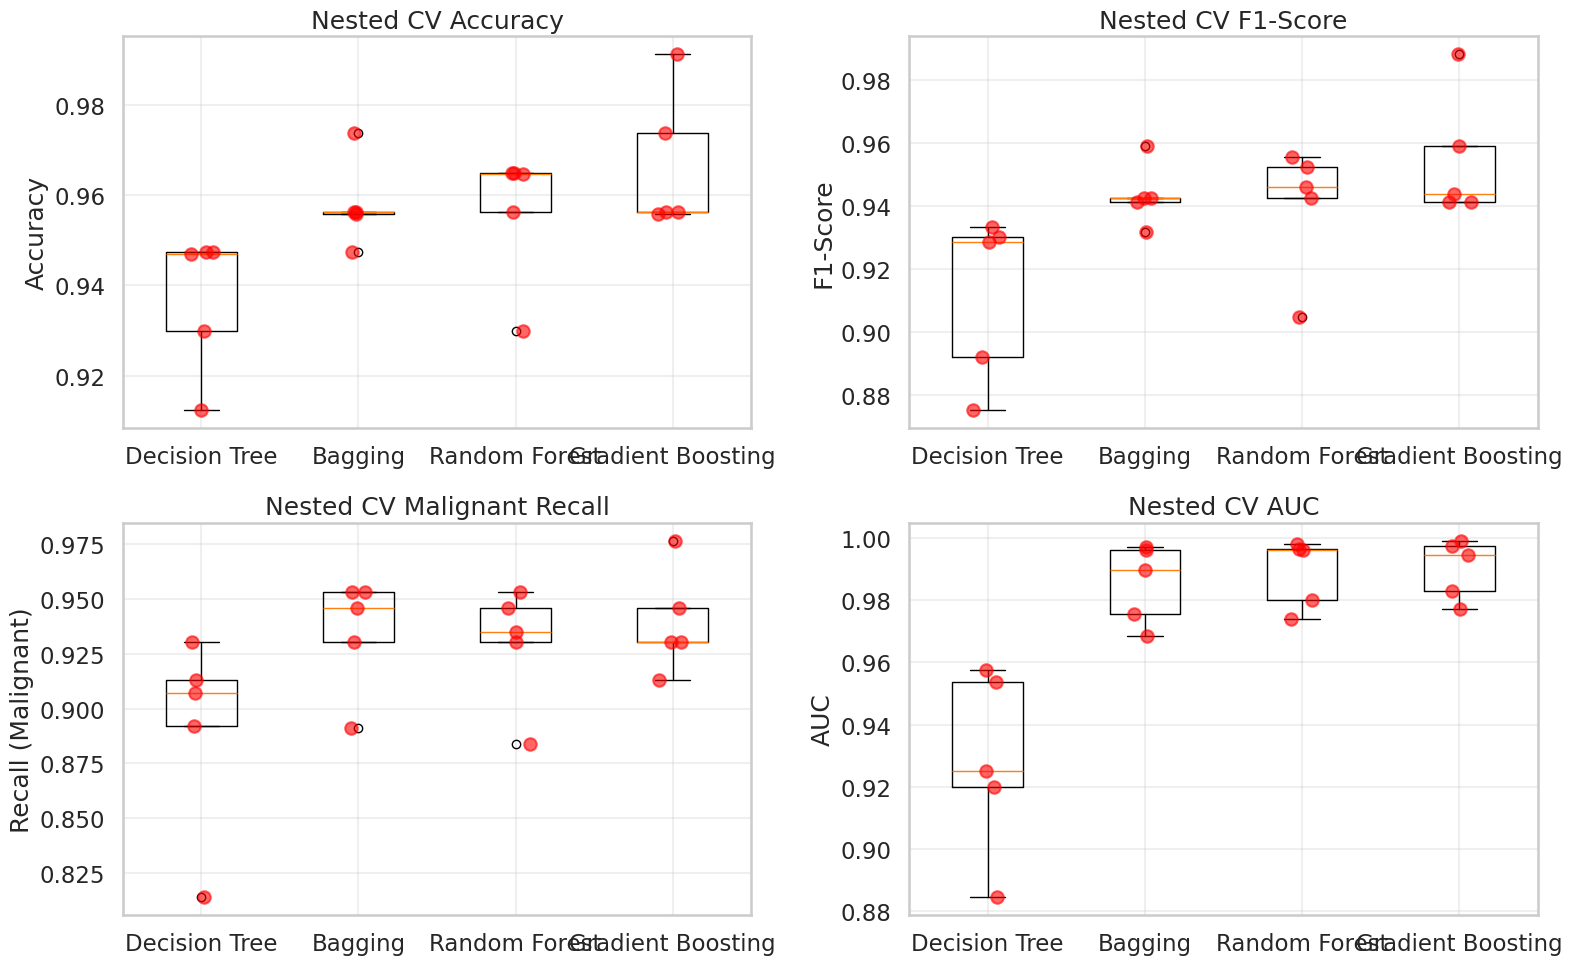

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
names = list(results.keys())

metrics = [
    ('accuracy', 'Nested CV Accuracy', 'Accuracy'),
    ('f1', 'Nested CV F1-Score', 'F1-Score'),
    ('recall', 'Nested CV Malignant Recall', 'Recall (Malignant)'),
    ('roc_auc', 'Nested CV AUC', 'AUC')
]

for ax, (key, title, ylabel) in zip(axes.flatten(), metrics):
    data_for_plot = [results[n][key] for n in names]
    ax.boxplot(data_for_plot, tick_labels=names)
    # Overlay individual data points
    for i, scores in enumerate(data_for_plot):
        x = np.random.normal(i + 1, 0.04, size=len(scores))
        ax.scatter(x, scores, alpha=0.6, color='red', zorder=3)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Interpreting the Results

### The Bias-Variance Story

Looking at the results, we can see the bias-variance tradeoff playing out:

- **Decision Tree**: Lowest mean accuracy and highest variance. A single tree is unstable — its performance depends heavily on which samples it sees.

- **Bagging**: Significant improvement over the single tree. Averaging bootstrap-trained trees cancels out individual errors, reducing variance.

- **Random Forest**: Statistically indistinguishable from bagging here — on this run its mean accuracy, F1, and recall land a hair *below* bagging's, though its AUC is the best of the parallel methods. The feature randomness that decorrelates the trees helps most when a few dominant features would otherwise make every bagged tree look alike; with only 5 outer folds, differences this small are within noise.

- **Gradient Boosting**: Typically achieves the highest accuracy and F1. By sequentially correcting errors, it reduces bias more effectively than the parallel methods. However, it may have slightly higher variance than the random forest because the trees are dependent on each other.

### The Malignant Recall Story

In a medical context, **malignant recall** is the most critical metric: it tells us what fraction of actual cancers each model catches on average.

Look at the recall boxplot above. The model with the highest mean recall catches the most cancers. But also look at the spread: a model with high mean recall but large variance is less reliable — in some folds it catches nearly all cancers, in others it misses many. For clinical deployment, you might prefer a slightly lower but more consistent recall.

### Which Model Should You Choose?

Based on our nested CV results, here's a practical guide:

| Scenario | Recommended Model | Why |
|---|---|---|
| Need interpretability | Decision Tree | Can print the flowchart |
| Need a quick, reliable baseline | Random Forest | Hard to mess up, parallelizable |
| Need maximum accuracy | Gradient Boosting | Best performance on tabular data |
| Need uncertainty estimates | BART | Provides credible intervals |
| Very large dataset | Random Forest | Scales better than boosting |
| Clinical deployment (catch cancers) | *See recall results above* | Choose the model with highest and most consistent malignant recall |

For the breast cancer diagnosis problem specifically, look at the malignant recall scores above. The model with the highest recall catches the most cancers, but if its variance is high, you might prefer the second-best model for more consistent performance.

### Nested CV vs. Single Train/Test Split

In the earlier notebooks, we evaluated each model on a single train/test split. A single split is one noisy draw: it can come out optimistic *or* pessimistic depending on which samples land in the test set, and tuning hyperparameters against the same training data adds an optimistic pull on top.

Here's how the single-split test accuracies from notebooks 1–3 compare to the nested CV estimates above:

| Model | Single-Split Test Acc | Nested CV Acc (mean) |
|---|---|---|
| Decision Tree (best depth) | 0.918 | 0.937 |
| Random Forest (500 trees) | 0.971 | 0.956 |
| Gradient Boosting (200 trees) | 0.965 | 0.967 |

For the Random Forest, the single split was optimistic by about 1.5 points. For the single tree, the split happened to be *pessimistic*. That inconsistency is exactly the point: a single test score gives you one number with no sense of how lucky it was. The nested CV mean ± standard deviation tells you both the expected performance and how much it varies with the data — information a single test score can never give you.

---
## Final Model: Best Performer on Full Data

Now that we've identified the best method, let's train it on the full dataset and examine its final performance.

In [5]:
# Find the best model by mean recall (most clinically relevant)
best_name = max(results.keys(), key=lambda n: results[n]['recall'].mean())
print(f"Best model by nested CV malignant recall: {best_name}")
print(f"Mean nested CV recall: {results[best_name]['recall'].mean():.4f} +/- {results[best_name]['recall'].std():.4f}")

# Train the best model on all data
best_config = model_configs[best_name]
best_model = GridSearchCV(
    best_config['model'],
    best_config['grid'],
    cv=5,
    scoring='recall',
    n_jobs=-1
)
best_model.fit(X, y)

print(f"\nBest parameters: {best_model.best_params_}")
print(f"Best CV Recall (full data): {best_model.best_score_:.4f}")
print(f"Best CV F1 (full data): {cross_val_score(best_model.best_estimator_, X, y, cv=5, scoring='f1').mean():.4f}")

Best model by nested CV malignant recall: Gradient Boosting
Mean nested CV recall: 0.9392 +/- 0.0214



Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Best CV Recall (full data): 0.9437


Best CV F1 (full data): 0.9482


### Final Model Performance

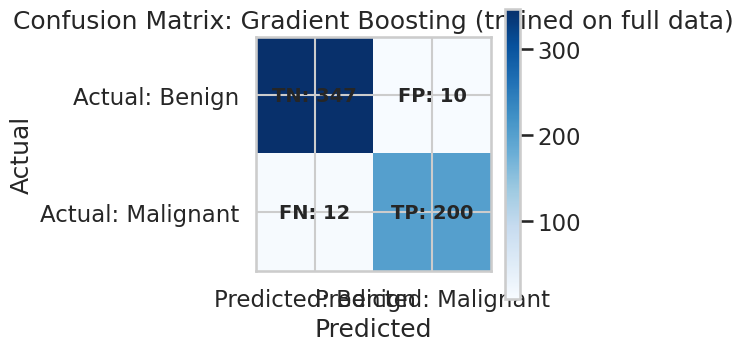


--- Medical Interpretation ---
Across 5-fold CV on full data:
  Missed cancers (FN): 12
  Unnecessary biopsies (FP): 10

--- Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.97      0.97      0.97       357
Malignant (1)       0.95      0.94      0.95       212

     accuracy                           0.96       569
    macro avg       0.96      0.96      0.96       569
 weighted avg       0.96      0.96      0.96       569



In [6]:
# Evaluate on full data with 5-fold CV
from sklearn.model_selection import cross_val_predict

y_pred_full = cross_val_predict(best_model.best_estimator_, X, y, cv=5)
cm = confusion_matrix(y, y_pred_full)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Benign', 'Predicted: Malignant'])
ax.set_yticklabels(['Actual: Benign', 'Actual: Malignant'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix: {best_name} (trained on full data)')

labels = [[f'TN: {tn}', f'FP: {fp}'], [f'FN: {fn}', f'TP: {tp}']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i][j], ha='center', va='center', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"\n--- Medical Interpretation ---")
print(f"Across 5-fold CV on full data:")
print(f"  Missed cancers (FN): {fn}")
print(f"  Unnecessary biopsies (FP): {fp}")
print(f"\n--- Classification Report ---")
print(classification_report(y, y_pred_full, target_names=['Benign (0)', 'Malignant (1)']))

### Feature Importance from the Final Model

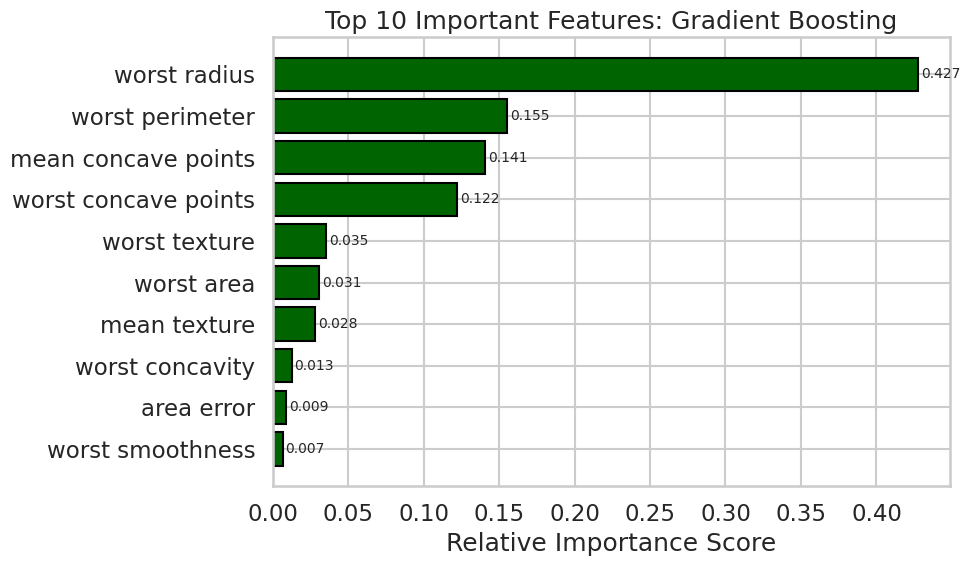

In [7]:
if hasattr(best_model.best_estimator_, 'feature_importances_'):
    importances = pd.Series(best_model.best_estimator_.feature_importances_, index=data.feature_names)
    top_10 = importances.sort_values(ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(range(len(top_10)), top_10.values, color='darkgreen', edgecolor='black')
    plt.yticks(range(len(top_10)), top_10.index)
    plt.gca().invert_yaxis()
    plt.xlabel('Relative Importance Score')
    plt.title(f'Top 10 Important Features: {best_name}')
    
    for bar, val in zip(bars, top_10.values):
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2.,
                 f'{val:.3f}', ha='left', va='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

### Your Turn

1. Look at the boxplots. Which model has the smallest interquartile range (most consistent performance)? Is this the same model with the highest mean?
2. The nested CV recall for the best model is printed above with its standard deviation. What does the standard deviation tell you about the model's reliability in a clinical setting?
3. If you were deploying this model in a hospital, would you choose the model with the highest mean recall or the one with the lowest variance? Justify your answer.
4. The final model trained on full data shows 12 missed cancers across 5-fold CV. If this model screened 10,000 patients with the same cancer rate, approximately how many cancers would be missed?

## Conclusion: The Ensemble Series Recap

Over four notebooks, we've explored the full spectrum of tree-based ensemble methods:

1. **Single Decision Tree** — The building block. Interpretable but unstable. Prone to overfitting.
2. **Bagging** — Reduces variance by averaging many bootstrap-trained trees. OOB error provides built-in validation.
3. **Random Forest** — Adds feature randomness to decorrelate trees. The go-to method for most tabular data problems.
4. **Gradient Boosting** — Reduces bias through sequential error correction. The most accurate method for structured data.
5. **BART** — Bayesian approach with uncertainty quantification. Ideal when you need to know how confident the model is.

### Key Takeaways

- **Ensembles beat single trees** — always. The wisdom of the crowd is real.
- **Bagging reduces variance; boosting reduces bias** — they solve different problems.
- **Hyperparameter tuning matters** — especially for boosting, where the learning rate and tree depth control the bias-variance tradeoff.
- **Classification metrics matter** — in medical diagnosis, recall (catching cancers) is more important than accuracy.
- **Nested CV gives honest estimates** — don't trust a single train/test split for model comparison.

Thank you for completing the 18_6 Ensemble Methods series!